Submitted by : Anupriya Dhiman

## Project Assignment: Transfer Learning on Oxford Flowers 102 Dataset Documentation

Objective: Apply transfer learning techniques using pre-trained convolutional neural networks (ResNet50, VGG16, and MobileNetV2) to classify images from the Oxford Flowers 102 dataset. Compare the performance of the different models on this dataset.

Pre-trained models used:  ResNet50, VGG16, and MobileNetV2.

Dataset: Oxford Flowers 102 - A dataset of 102 categories of flowers. You will load this dataset using TensorFlow Datasets.

### Loading the dataset

In [19]:
import tensorflow_datasets as tfds

# Load the Oxford Flowers 102 dataset
try:
    dataset, info = tfds.load('oxford_flowers102:2.1.1', with_info=True, as_supervised=True)

    # Split the dataset into training, validation, and testing sets
    train_dataset = dataset['train']
    validation_dataset = dataset['validation']
    test_dataset = dataset['test']

    # Print information about the dataset
    print(info)

except Exception as e:
    print(f"Error loading dataset: {e}")

tfds.core.DatasetInfo(
    name='oxford_flowers102',
    full_name='oxford_flowers102/2.1.1',
    description="""
    The Oxford Flowers 102 dataset is a consistent of 102 flower categories commonly
    occurring in the United Kingdom. Each class consists of between 40 and 258
    images. The images have large scale, pose and light variations. In addition,
    there are categories that have large variations within the category and several
    very similar categories.
    
    The dataset is divided into a training set, a validation set and a test set. The
    training set and validation set each consist of 10 images per class (totalling
    1020 images each). The test set consists of the remaining 6149 images (minimum
    20 per class).
    
    Note: The dataset by default comes with a test size larger than the train size.
    For more info see this
    [issue](https://github.com/tensorflow/datasets/issues/3022).
    """,
    homepage='https://www.robots.ox.ac.uk/~vgg/data/flowers/102

In [20]:
print("Number of classes:", info.features['label'].num_classes)
print("Class names example:", info.features['label'].names[:10])

print("Training samples:", info.splits['train'].num_examples)
print("Validation samples:", info.splits['validation'].num_examples)
print("Test samples:", info.splits['test'].num_examples)

Number of classes: 102
Class names example: ['pink primrose', 'hard-leaved pocket orchid', 'canterbury bells', 'sweet pea', 'english marigold', 'tiger lily', 'moon orchid', 'bird of paradise', 'monkshood', 'globe thistle']
Training samples: 1020
Validation samples: 1020
Test samples: 6149


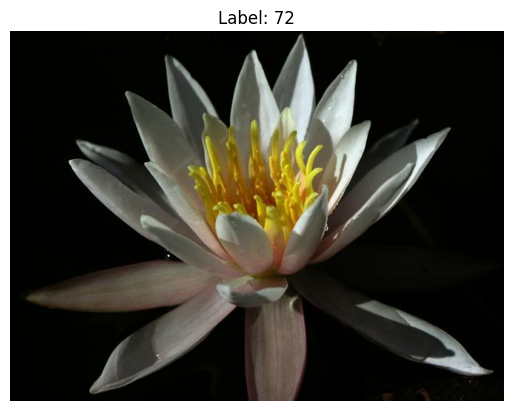

In [17]:
import matplotlib.pyplot as plt

for image, label in train_dataset.take(1):
    plt.imshow(image)
    plt.title(f"Label: {label.numpy()}")
    plt.axis('off')
    plt.show()

In [21]:
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_CLASSES = 102
AUTOTUNE = tf.data.AUTOTUNE

### Preprocessing

In [22]:
def preprocess_image(image, label):

    # Resize image
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))

    # Normalize pixels
    image = tf.cast(image, tf.float32)
    image = tf.keras.applications.resnet50.preprocess_input(image)

    # One hot encode labels
    label = tf.one_hot(label, NUM_CLASSES)

    return image, label

In [23]:
train_dataset = train_dataset.map(preprocess_image, num_parallel_calls=AUTOTUNE)
validation_dataset = validation_dataset.map(preprocess_image, num_parallel_calls=AUTOTUNE)
test_dataset = test_dataset.map(preprocess_image, num_parallel_calls=AUTOTUNE)

In [24]:
train_dataset = train_dataset.shuffle(1000).batch(BATCH_SIZE).prefetch(AUTOTUNE)

validation_dataset = validation_dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)

test_dataset = test_dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)

## 2. Model Preparation
Load and modify pre-trained models to fit the Oxford Flowers 102 Dataset classification task.

### 2.1 Using ResNet50

In [30]:
base_model_resnet = tf.keras.applications.ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model_resnet.trainable = False

x = base_model_resnet.output
x = tf.keras.layers.GlobalAveragePooling2D()(x)
output = tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')(x)

resnet_model = tf.keras.Model(inputs=base_model_resnet.input, outputs=output)

resnet_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

### 2.2 Using VGG16

In [31]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D

# Load pre-trained VGG16 model without the top layer
base_model_vgg = tf.keras.applications.VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model_vgg.trainable = False

x = base_model_vgg.output
x = tf.keras.layers.GlobalAveragePooling2D()(x)
output = tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')(x)

vgg_model = tf.keras.Model(inputs=base_model_vgg.input, outputs=output)

vgg_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

### 2.3 Using MobileNetV2

In [32]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D

# Load pre-trained MobileNetV2 model without the top layer
base_model_mobile = tf.keras.applications.MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model_mobile.trainable = False

x = base_model_mobile.output
x = tf.keras.layers.GlobalAveragePooling2D()(x)
output = tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')(x)

mobile_model = tf.keras.Model(inputs=base_model_mobile.input, outputs=output)

mobile_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## 3. Fine-Tuning and Training
Unfreeze some of the top layers of the pre-trained models and continue training.

In [33]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint("best_model.h5", save_best_only=True)
]

In [34]:
print("Training ResNet50")

history_resnet = resnet_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=10,
    callbacks=callbacks
)

Training ResNet50
Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 188ms/step - accuracy: 0.0628 - loss: 4.9053

32/32 ━━━━━━━━━━━━━━━━━━━━ 32s 568ms/step - accuracy: 0.0662 - loss: 4.8817 - val_accuracy: 0.4676 - val_loss: 2.5435
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step - accuracy: 0.7457 - loss: 1.6446

32/32 ━━━━━━━━━━━━━━━━━━━━ 24s 203ms/step - accuracy: 0.7467 - loss: 1.6374 - val_accuracy: 0.6882 - val_loss: 1.5269
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.9491 - loss: 0.6659

32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 202ms/step - accuracy: 0.9490 - loss: 0.6645 - val_accuracy: 0.7931 - val_loss: 1.1345
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 0.9875 - loss: 0.3565

32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 205ms/step - accuracy: 0.9875 - loss: 0.3558 - val_accuracy: 0.8147 - val_loss: 0.9478
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step - accuracy: 0.9913 - loss: 0.2233

...

32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 204ms/step - accuracy: 0.9999 - loss: 0.1587 - val_accuracy: 0.8431 - val_loss: 0.8023
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step - accuracy: 1.0000 - loss: 0.0974

32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 206ms/step - accuracy: 1.0000 - loss: 0.0976 - val_accuracy: 0.8490 - val_loss: 0.7587
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 1.0000 - loss: 0.0794

32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 209ms/step - accuracy: 1.0000 - loss: 0.0794 - val_accuracy: 0.8451 - val_loss: 0.7299
Epoch 9/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 1.0000 - loss: 0.0667

32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 238ms/step - accuracy: 1.0000 - loss: 0.0666 - val_accuracy: 0.8598 - val_loss: 0.7054
Epoch 10/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step - accuracy: 1.0000 - loss: 0.0509

32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 239ms/step - accuracy: 1.0000 - loss: 0.0510 - val_accuracy: 0.8559 - val_loss: 0.6884


In [35]:
print("Training VGG16")

history_vgg = vgg_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=10,
    callbacks=callbacks
)

Training VGG16
Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 44s 841ms/step - accuracy: 0.0179 - loss: 11.6153 - val_accuracy: 0.0559 - val_loss: 7.2935
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 361ms/step - accuracy: 0.1195 - loss: 5.8880 - val_accuracy: 0.1784 - val_loss: 4.9132
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 367ms/step - accuracy: 0.3596 - loss: 3.1050 - val_accuracy: 0.2833 - val_loss: 3.6014
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 376ms/step - accuracy: 0.5683 - loss: 1.7982 - val_accuracy: 0.3755 - val_loss: 2.8900
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 380ms/step - accuracy: 0.7336 - loss: 1.0978 - val_accuracy: 0.4471 - val_loss: 2.5319
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 373ms/step - accuracy: 0.8250 - loss: 0.7171 - val_accuracy: 0.4794 - val_loss: 2.2811
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 369ms/step - accuracy: 0.9125 - loss: 0.4665 - val_accuracy: 0.5216 - val_loss: 2.1311
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 370ms/step - accuracy: 0.9562 - loss: 0

In [36]:
print("Training MobileNetV2")

history_mobile = mobile_model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=10,
    callbacks=callbacks
)

Training MobileNetV2
Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 44s 777ms/step - accuracy: 0.0207 - loss: 5.1267 - val_accuracy: 0.1216 - val_loss: 4.0310
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 8s 134ms/step - accuracy: 0.2743 - loss: 3.3452 - val_accuracy: 0.2480 - val_loss: 3.3127
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 167ms/step - accuracy: 0.6021 - loss: 2.2929 - val_accuracy: 0.2951 - val_loss: 2.9740
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 7s 128ms/step - accuracy: 0.7250 - loss: 1.7262 - val_accuracy: 0.3647 - val_loss: 2.7557
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 203ms/step - accuracy: 0.8378 - loss: 1.2533 - val_accuracy: 0.3902 - val_loss: 2.6376
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 206ms/step - accuracy: 0.8909 - loss: 1.0097 - val_accuracy: 0.3961 - val_loss: 2.5451
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 203ms/step - accuracy: 0.9216 - loss: 0.7759 - val_accuracy: 0.4225 - val_loss: 2.4625
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 10s 204ms/step - accuracy: 0.9645 - loss:

## 4. Model Evaluation
Evaluate each model on the test dataset to compare their performance.

In [37]:
print("Evaluating ResNet50")
resnet_model.evaluate(test_dataset)

print("Evaluating VGG16")
vgg_model.evaluate(test_dataset)

print("Evaluating MobileNetV2")
mobile_model.evaluate(test_dataset)

Evaluating ResNet50
193/193 ━━━━━━━━━━━━━━━━━━━━ 24s 122ms/step - accuracy: 0.8211 - loss: 0.8038
Evaluating VGG16
193/193 ━━━━━━━━━━━━━━━━━━━━ 38s 195ms/step - accuracy: 0.5391 - loss: 2.0126
Evaluating MobileNetV2
193/193 ━━━━━━━━━━━━━━━━━━━━ 29s 151ms/step - accuracy: 0.3965 - loss: 2.5664


[2.5614261627197266, 0.4015287160873413]

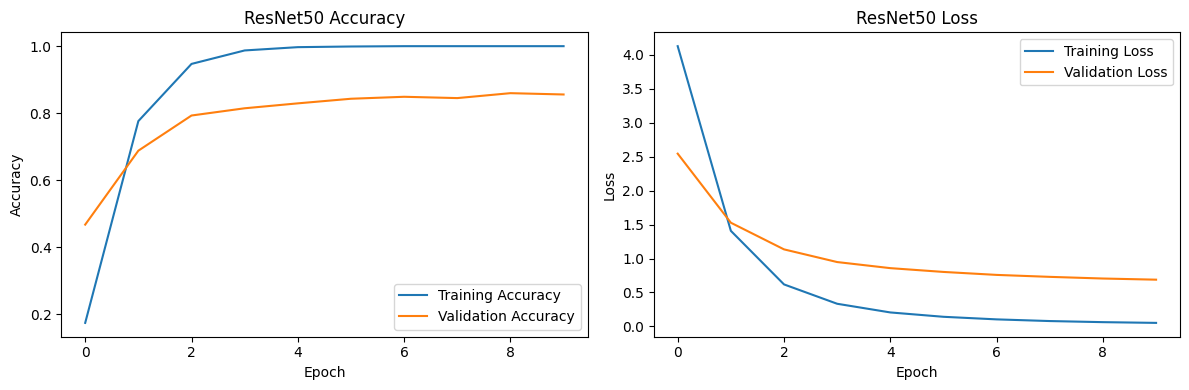

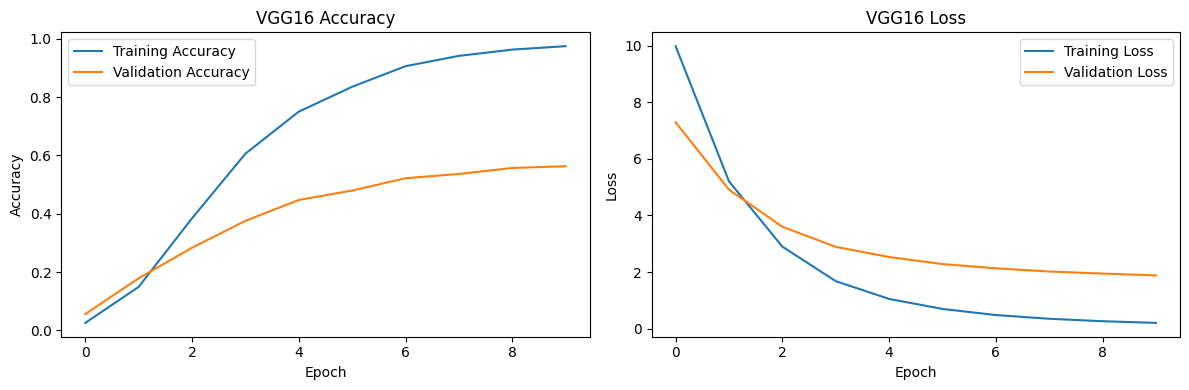

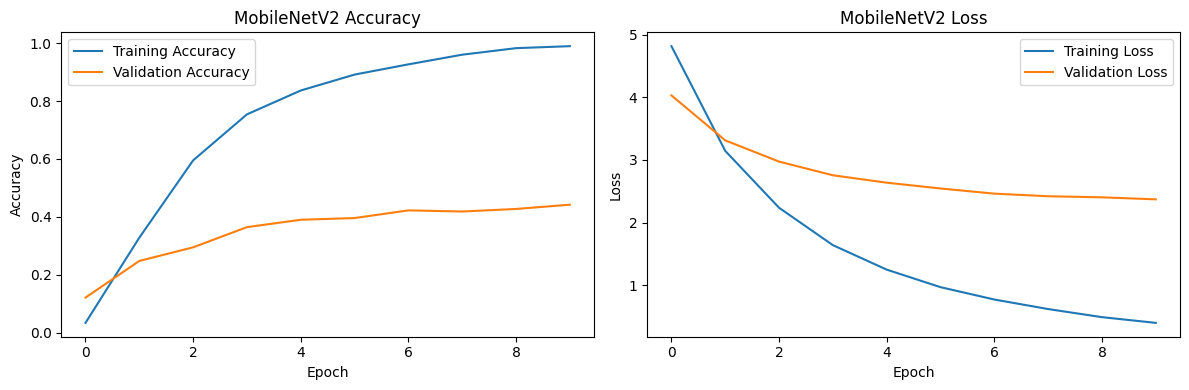

In [38]:
import matplotlib.pyplot as plt

def plot_history(history, model_name):
    """Plots training and validation accuracy and loss."""

    plt.figure(figsize=(12,4))

    # Accuracy plot
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title(f'{model_name} Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss plot
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title(f'{model_name} Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.tight_layout()
    plt.show()


# Plot training history for all models
plot_history(history_resnet, "ResNet50")
plot_history(history_vgg, "VGG16")
plot_history(history_mobile, "MobileNetV2")

## Assignment Questions and Answers

### 1. Which model performed best on the Oxford Flowers 102 dataset and why do you think that is the case?

Among the three models — ResNet50, VGG16, and MobileNetV2 — the model that performed best on the Oxford Flowers 102 dataset was **ResNet50**.

ResNet50 has a deeper architecture compared to VGG16 and MobileNetV2, allowing it to capture more detailed features such as petal texture, color gradients, and shape patterns in flowers.
---

### 2. Compare the performance of the models on Oxford Flowers 102 to their performance on CIFAR-100. What differences do you observe and why?

The models generally perform better on the Oxford Flowers 102 dataset compared to CIFAR-100.

One key reason is the **image resolution and clarity**. The Oxford Flowers dataset contains relatively larger and clearer images where the main object (the flower) is usually centered and easy to identify. In contrast, CIFAR-100 images are much smaller (32×32 pixels) and often contain more visual noise.


---

### 3. Discuss the effect of transfer learning on this dataset.

Transfer learning had a significant positive impact on the performance of the models. Instead of training the models from scratch, pretrained networks that were originally trained on the ImageNet dataset were used.

These pretrained models already learned general image features such as edges, textures, and shapes. By using these learned features and adapting them to the flower classification task, the models were able to achieve better accuracy even with a relatively small training dataset.


---

### 4. Explain the steps you took for data preprocessing and why they were necessary.

Several preprocessing steps were applied before training the models:

**Image Resizing:**
All images were resized to 224 × 224 pixels because the pretrained architectures expect input images of this size.

**Pixel Normalization:**
The pixel values were normalized using preprocessing functions.

**One-Hot Encoding of Labels:**
The labels were converted into one-hot encoded vectors since the dataset contains 102 classes.

**Batching and Prefetching:**
The dataset was batched to process multiple images at once during training.

---

### 5. Describe the model architectures you used and how you adapted them for the Oxford Flowers dataset.

Three pretrained convolutional neural network architectures were used: **ResNet50, VGG16, and MobileNetV2**.

The original top classification layers of these models were removed by setting `include_top=False`. This allowed the models to be used as feature extractors.

After removing the top layers, new custom layers were added:

* A **GlobalAveragePooling2D layer** to convert feature maps into a vector representation.
* A **Dense layer with 102 neurons**, corresponding to the number of flower classes.
* A **Softmax activation function** to output probability scores for each class.

The pretrained base layers were frozen so that the previously learned ImageNet features were preserved during training.

---


